<a href="https://colab.research.google.com/github/cq88661/232e-proj1/blob/sia/232e-proj1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.1(a)**

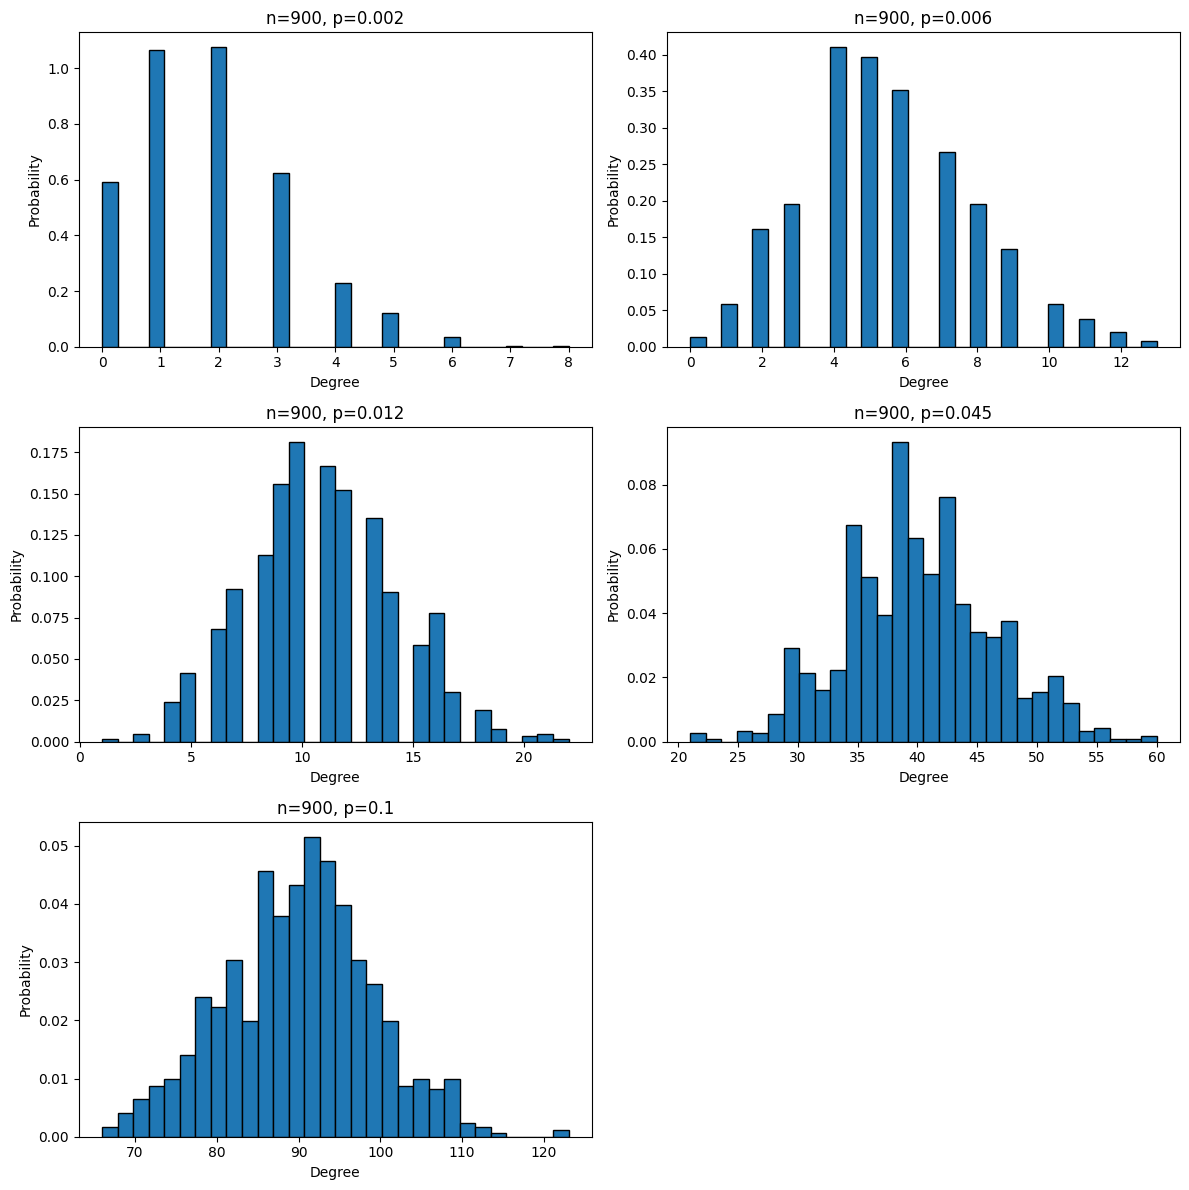

       p  Empirical Mean  Theoretical Mean  Empirical Variance  \
0  0.002        1.833333             1.798            1.798889   
1  0.006        5.497778             5.394            5.632217   
2  0.012       10.846667            10.788           11.145378   
3  0.045       40.040000            40.455           38.400622   
4  0.100       89.951111            89.900           81.253165   

   Theoretical Variance  
0              1.794404  
1              5.361636  
2             10.658544  
3             38.634525  
4             80.910000  


In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]

results = []

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, p in enumerate(p_values):
    G = nx.gnp_random_graph(n, p, seed=42)
    degrees = np.array([d for _, d in G.degree()])

    axes[i].hist(
        degrees,
        bins=30,
        density=True,
        edgecolor='black'
    )
    axes[i].set_title(f'n={n}, p={p}')
    axes[i].set_xlabel('Degree')
    axes[i].set_ylabel('Probability')

    empirical_mean = np.mean(degrees)
    empirical_variance = np.var(degrees)

    theoretical_mean = (n - 1) * p
    theoretical_variance = (n - 1) * p * (1 - p)

    results.append({
        'p': p,
        'Empirical Mean': empirical_mean,
        'Theoretical Mean': theoretical_mean,
        'Empirical Variance': empirical_variance,
        'Theoretical Variance': theoretical_variance
    })

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Print results table
df = pd.DataFrame(results)
print(df)



** Explanation **

The observed degree distribution is theoretically a binomial distribution.

For smaller values of p, the degree distribution appears right-skewed and resembles a Poisson or exponential-like distribution.

As p increases, the mean degree np becomes larger, and the binomial distribution approaches a Gaussian (normal) distribution by the central limit theorem.

From the above results, we can tell the empirical means and variances closely match the theoretical values predicted by the binomial distribution.


**1.1(b)**

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd

n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]
num_trials = 100
seed_base = 42

results = []

for p in p_values:
    connected_count = 0

    for trial in range(num_trials):
        G = nx.gnp_random_graph(n, p, seed=seed_base + trial)
        if nx.is_connected(G):
            connected_count += 1

    prob_connected = connected_count / num_trials

    G_instance = nx.gnp_random_graph(n, p, seed=seed_base + 1000)

    if nx.is_connected(G_instance):
        gcc = G_instance
        gcc_size = G_instance.number_of_nodes()
        gcc_diameter = nx.diameter(gcc)
        connected_status = True
    else:
        connected_status = False

        components = list(nx.connected_components(G_instance))

        gcc_nodes = max(components, key=len)
        gcc = G_instance.subgraph(gcc_nodes).copy()
        gcc_size = gcc.number_of_nodes()
        gcc_diameter = nx.diameter(gcc)

    results.append({
        "p": p,
        "Estimated P(connected)": prob_connected,
        "Example network connected?": connected_status,
        "GCC size": gcc_size,
        "GCC diameter": gcc_diameter
    })

df = pd.DataFrame(results)

print(df)

       p  Estimated P(connected)  Example network connected?  GCC size  \
0  0.002                    0.00                       False       654   
1  0.006                    0.05                       False       894   
2  0.012                    0.99                        True       900   
3  0.045                    1.00                        True       900   
4  0.100                    1.00                        True       900   

   GCC diameter  
0            24  
1             8  
2             6  
3             3  
4             3  


**1.1(c)**

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

n = 900
num_trials = 100
rng_seed = 42

p_giant_theory = 1 / n
p_connect_theory = np.log(n) / n

print(f"Theoretical giant-component threshold ~ 1/n = {p_giant_theory:.6f}")
print(f"Theoretical connectivity threshold ~ ln(n)/n = {p_connect_theory:.6f}")


pmax = 0.02

p_values = np.concatenate([
    np.linspace(0.0000, 0.0030, 31),
    np.linspace(0.0032, 0.0100, 35),
    np.linspace(0.0105, pmax, 20)
])
p_values = np.unique(np.round(p_values, 6))


records = []

seed_counter = rng_seed

for p in p_values:
    for trial in range(num_trials):
        G = nx.gnp_random_graph(n, p, seed=seed_counter)
        seed_counter += 1

        if G.number_of_edges() == 0:
            gcc_size = 1 if n > 0 else 0
        else:
            gcc_size = len(max(nx.connected_components(G), key=len))

        gcc_frac = gcc_size / n

        records.append({
            "p": p,
            "trial": trial,
            "gcc_size": gcc_size,
            "gcc_frac": gcc_frac
        })

df = pd.DataFrame(records)

summary = df.groupby("p").agg(
    mean_gcc_frac=("gcc_frac", "mean"),
    median_gcc_frac=("gcc_frac", "median"),
    std_gcc_frac=("gcc_frac", "std"),
    min_gcc_frac=("gcc_frac", "min"),
    max_gcc_frac=("gcc_frac", "max"),
    frac_trials_gcc_over_10pct=("gcc_frac", lambda x: np.mean(x >= 0.10)),
    frac_trials_gcc_over_50pct=("gcc_frac", lambda x: np.mean(x >= 0.50)),
    frac_trials_gcc_over_99pct=("gcc_frac", lambda x: np.mean(x >= 0.99))
).reset_index()


emergence_candidates = summary[
    (summary["mean_gcc_frac"] >= 0.10) &
    (summary["frac_trials_gcc_over_10pct"] >= 0.50)
]

if len(emergence_candidates) > 0:
    p_emergence = emergence_candidates.iloc[0]["p"]
else:
    p_emergence = None


almost_every_candidates = summary[
    summary["frac_trials_gcc_over_99pct"] >= 0.95
]

if len(almost_every_candidates) > 0:
    p_99_almost_every = almost_every_candidates.iloc[0]["p"]
else:
    p_99_almost_every = None


plt.figure(figsize=(11, 7))

plt.scatter(df["p"], df["gcc_frac"], alpha=0.25, s=12, label="100 realizations per p")

plt.plot(summary["p"], summary["mean_gcc_frac"], linewidth=2.5, label="Average normalized GCC size")

plt.axvline(p_giant_theory, linestyle="--", linewidth=1.8, label=r"Theory: $1/n$")
plt.axvline(p_connect_theory, linestyle="--", linewidth=1.8, label=r"Theory: $\ln(n)/n$")

if p_emergence is not None:
    plt.axvline(p_emergence, linestyle=":", linewidth=2,
                label=f"Empirical emergence ≈ {p_emergence:.4f}")

if p_99_almost_every is not None:
    plt.axvline(p_99_almost_every, linestyle=":", linewidth=2,
                label=f"Empirical >99% almost always ≈ {p_99_almost_every:.4f}")

plt.xlabel("p")
plt.ylabel("Normalized GCC size")
plt.title(f"Normalized GCC size vs p for ER graphs, n={n}")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Empirical threshold estimates ---")
if p_emergence is not None:
    print(f"Giant component emergence threshold (empirical) ≈ {p_emergence:.6f}")
else:
    print("No emergence threshold found under the chosen criterion.")

if p_99_almost_every is not None:
    print(f"GCC > 99% in almost every experiment (empirical) ≈ {p_99_almost_every:.6f}")
else:
    print("No p found where GCC > 99% in almost every experiment under the chosen criterion.")

print("\n--- Theory comparison ---")
print(f"Theoretical giant-component threshold ~ 1/n = {p_giant_theory:.6f}")
print(f"Theoretical connectivity threshold ~ ln(n)/n = {p_connect_theory:.6f}")

interesting = summary[
    (summary["p"] >= 0.0000) & (summary["p"] <= 0.0120)
].copy()

print("\n--- Summary table (first 20 rows) ---")
print(interesting.head(20).to_string(index=False))



Theoretical giant-component threshold ~ 1/n = 0.001111
Theoretical connectivity threshold ~ ln(n)/n = 0.007558


The empirical giant-component emergence threshold (0.0012) is very close to the theoretical threshold 0.001111. Therefore, the simulation agrees well with theory. The empirical threshold where the GCC exceeds 99% of nodes in almost every run is 0.0058, which is below the theoretical connectivity threshold 0.007558 as expected since near-total GCC size does not require full graph connectivity.

**1.1(d)**

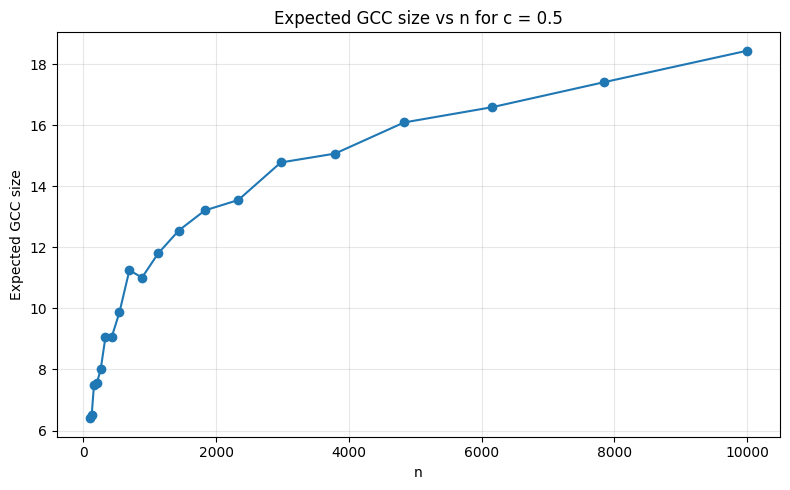

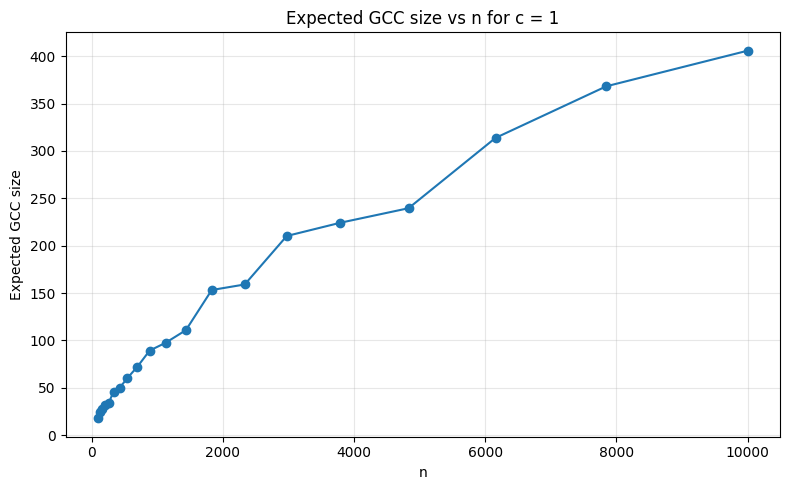

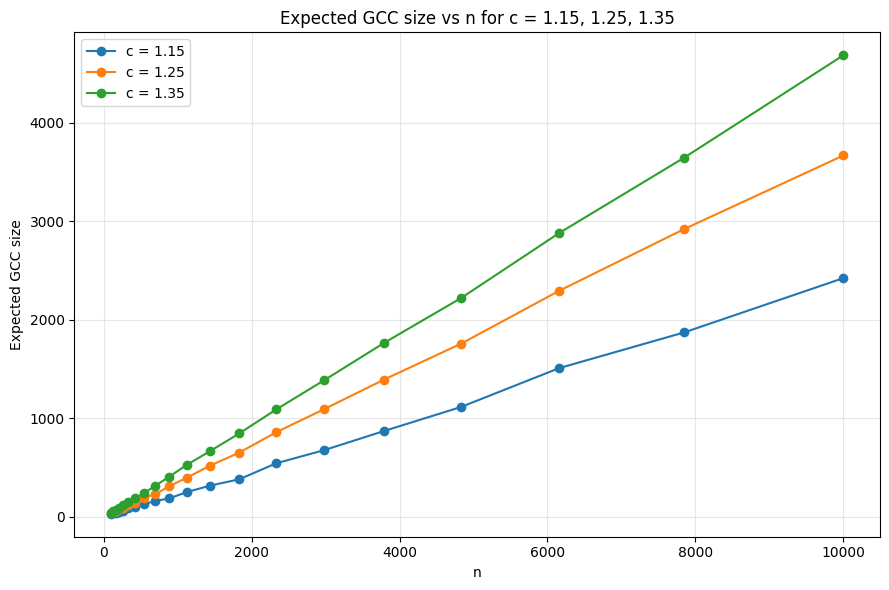

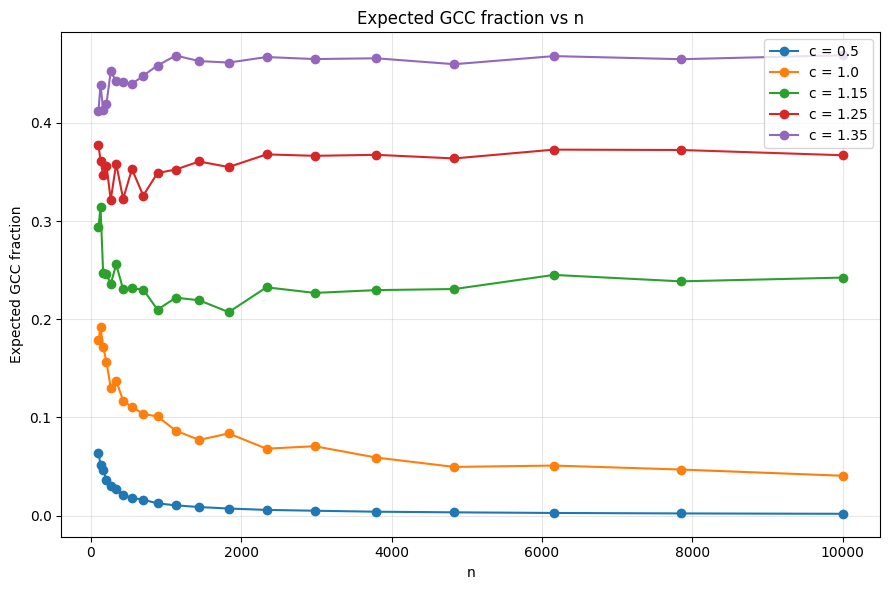


Results for c = 0.5
    n        p  expected_gcc_size  expected_gcc_fraction
  100 0.005000               6.40               0.064000
  127 0.003937               6.51               0.051260
  162 0.003086               7.50               0.046296
  206 0.002427               7.56               0.036699
  263 0.001901               8.01               0.030456
  335 0.001493               9.07               0.027075
  428 0.001168               9.06               0.021168
  545 0.000917               9.87               0.018110
  695 0.000719              11.25               0.016187
  885 0.000565              11.01               0.012441
 1128 0.000443              11.80               0.010461
 1438 0.000348              12.55               0.008727
 1832 0.000273              13.21               0.007211
 2335 0.000214              13.55               0.005803
 2976 0.000168              14.78               0.004966
 3792 0.000132              15.07               0.003974
 4832 0.00

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


np.random.seed(42)

n_values = np.unique(np.logspace(np.log10(100), np.log10(10000), 20, dtype=int))

num_trials = 100

c_values_single = [0.5, 1.0]
c_values_multi = [1.15, 1.25, 1.35]


def estimate_expected_gcc_size(n, c, num_trials=100, seed_start=0):

    p = c / n
    gcc_sizes = []

    for t in range(num_trials):
        G = nx.gnp_random_graph(n, p, seed=seed_start + t)

        if G.number_of_edges() == 0:
            gcc_size = 1
        else:
            gcc_size = len(max(nx.connected_components(G), key=len))

        gcc_sizes.append(gcc_size)

    gcc_sizes = np.array(gcc_sizes)
    return gcc_sizes.mean(), gcc_sizes.std(), (gcc_sizes / n).mean()

records = []
seed_counter = 1000

for c in [0.5, 1.0] + c_values_multi:
    for n in n_values:
        mean_gcc, std_gcc, mean_gcc_frac = estimate_expected_gcc_size(
            n=n,
            c=c,
            num_trials=num_trials,
            seed_start=seed_counter
        )
        seed_counter += num_trials

        records.append({
            "c": c,
            "n": n,
            "p": c / n,
            "expected_gcc_size": mean_gcc,
            "std_gcc_size": std_gcc,
            "expected_gcc_fraction": mean_gcc_frac
        })

df = pd.DataFrame(records)


df_c05 = df[df["c"] == 0.5]

plt.figure(figsize=(8, 5))
plt.plot(df_c05["n"], df_c05["expected_gcc_size"], marker='o')
plt.xlabel("n")
plt.ylabel("Expected GCC size")
plt.title("Expected GCC size vs n for c = 0.5")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


df_c1 = df[df["c"] == 1.0]

plt.figure(figsize=(8, 5))
plt.plot(df_c1["n"], df_c1["expected_gcc_size"], marker='o')
plt.xlabel("n")
plt.ylabel("Expected GCC size")
plt.title("Expected GCC size vs n for c = 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for c in c_values_multi:
    temp = df[df["c"] == c]
    plt.plot(temp["n"], temp["expected_gcc_size"], marker='o', label=f"c = {c}")

plt.xlabel("n")
plt.ylabel("Expected GCC size")
plt.title("Expected GCC size vs n for c = 1.15, 1.25, 1.35")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 6))
for c in [0.5, 1.0, 1.15, 1.25, 1.35]:
    temp = df[df["c"] == c]
    plt.plot(temp["n"], temp["expected_gcc_fraction"], marker='o', label=f"c = {c}")

plt.xlabel("n")
plt.ylabel("Expected GCC fraction")
plt.title("Expected GCC fraction vs n")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("\nResults for c = 0.5")
print(df[df["c"] == 0.5][["n", "p", "expected_gcc_size", "expected_gcc_fraction"]].to_string(index=False))

print("\nResults for c = 1")
print(df[df["c"] == 1.0][["n", "p", "expected_gcc_size", "expected_gcc_fraction"]].to_string(index=False))

print("\nResults for c = 1.15, 1.25, 1.35")
print(df[df["c"].isin(c_values_multi)][["c", "n", "p", "expected_gcc_size", "expected_gcc_fraction"]].to_string(index=False))